# Fraud Detection - Research & Model Development

This notebook documents the research and development of an optimized XGBoost classifier for credit card fraud detection. 

### Research Methodology & Key Pointers:
- **Stratified Splitting**: Used to preserve the highly imbalanced class distribution (0.17% fraud) across training and test sets, ensuring the model is evaluated on a representative sample of minority cases.
- **XGBoost Classifier**: A high-performance gradient boosting model optimized via `GridSearchCV` and `scale_pos_weight`. This ensures the model penalizes misclassification of fraud more heavily than legitimate transactions.
- **SHAP Interpretability**: Implemented both global (summary) and local (waterfall) explanations. This provides transparency into which features (like V14, V17) are the primary drivers of fraud risk, both across the dataset and for individual suspicious transactions.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import (
    train_test_split,
    ParameterGrid,
    learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    average_precision_score, 
    precision_recall_curve, 
    confusion_matrix,
    brier_score_loss, 
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

import dagshub
import mlflow

dagshub.init(
    repo_owner='mayank2004201',
    repo_name='fraud-detection-api',
    mlflow=True
)

# Set visual style for research plots
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)

c:\Mayank\Projects\fraud-detection-api\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as mayank2004201

Initialized MLflow to track repo "mayank2004201/fraud-detection-api"

Repository mayank2004201/fraud-detection-api initialized!

## 1. Data Preparation
Loading the Kaggle Credit Card Fraud dataset and preparing it for modeling. Since the dataset is highly imbalanced (0.17% fraud), we use stratified splitting.

In [2]:
# Global Parameters
DATA_PATH = "../data/creditcard.csv"
SEED = 42

# Load data
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")

# Feature/Target Split
X = df.drop("Class", axis=1)
y = df["Class"]

# Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# Scaling: Time and Amount need scaling as V1-V28 are already PCA-transformed
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print("Data preparation complete.")

Dataset shape: (284807, 31)
Data preparation complete.


## 1.1. Data Quality Audit
Before modeling, we audit the dataset for missing values and visualize the class imbalance and feature distributions (like transaction `Amount`) to ensure data integrity.

**Missing Values**

In [3]:
# Missing values check
print("Missing values per column:")
print(df.isnull().sum().sum())

Missing values per column:
0


**Visualizing Class Imbalancce**

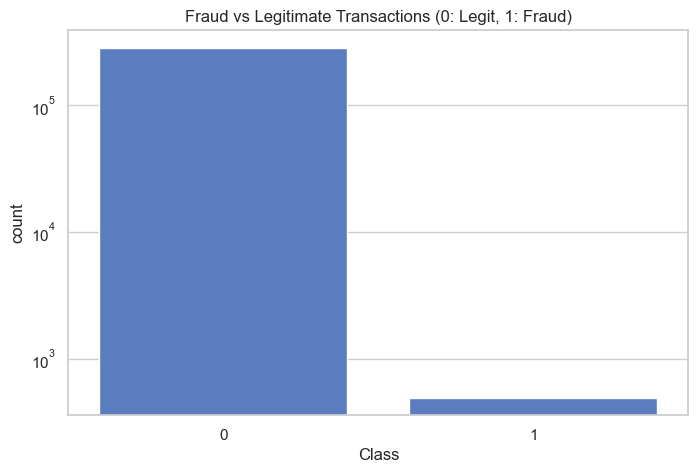

In [4]:
# Class distribution visualization
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions (0: Legit, 1: Fraud)')
plt.yscale('log') # Log scale to see the minority class clearly
plt.show()

**Feature Distribution**

In [5]:
print("Amount statistics for Fraud cases:")
print(df[df['Class'] == 1]['Amount'].describe())

Amount statistics for Fraud cases:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


## 2. MLflow Experiment Tracking
Logging and managing model experiments using MLflow and DagsHub.

### 2.1. MLflow Initialization & Configuration
Initiating the MLflow logging function and setting up DagsHub tracking.

In [6]:
mlflow.set_experiment("xgb-fraud-detection")

<Experiment: artifact_location='mlflow-artifacts:/f2ed27c1b7494e9ba6d0fd550cc8982c', creation_time=1774506257644, experiment_id='0', last_update_time=1774506257644, lifecycle_stage='active', name='xgb-fraud-detection', tags={}, workspace='default'>

### 2.2. Hyperparameter Space Definition
Defining the parameter grid for the XGBoost model experiments.

In [11]:
params_grid = {
    "n_estimators": [i for i in range(50,500,50)],
    "max_depth": [j for j in range(10,50,2)],
    "learning_rate": [0.2],
    # 0.001, 0.01, 0.05, 0.1,
    "scale_pos_weight" : [(y_train == 0).sum() / (y_train == 1).sum()]
}

### 2.3. Experiment Execution & Logging
Running model experiments and logging metrics and artifacts to MLflow.

In [12]:
for params in ParameterGrid(params_grid):
    with mlflow.start_run():
        model = XGBClassifier(
            **params,
            use_label_encoder = False,
            eval_metric = 'logloss',
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',        # ← Fastest histogram method on CPU
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train,y_train)
        
        probs = model.predict_proba(X_test)[:,1]
        preds = (probs > 0.3).astype(int)

        # METRICS
        mlflow.log_params(params)
        mlflow.log_metric("accuracy", accuracy_score(y_test, preds))
        mlflow.log_metric("precision", precision_score(y_test, preds))
        mlflow.log_metric("recall", recall_score(y_test, preds))
        mlflow.log_metric("f1_score", f1_score(y_test, preds))
        mlflow.log_metric("pr_auc", average_precision_score(y_test, probs))

        # Log model
        mlflow.xgboost.log_model(model, "model")

2026/03/30 14:24:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 14:24:10 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run bedecked-skunk-978 at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/1c7780b232164e3bbd3dd8f86490481d
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


2026/03/30 14:24:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 14:24:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run dapper-fox-808 at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/17bdadf2a87e4ae096544148e0360e5b
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


2026/03/30 14:24:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 14:25:01 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


...

🏃 View run vaunted-pig-631 at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/cd49a04d3cc2461699c4f615bf794199
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


2026/03/30 15:52:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 15:53:04 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run bustling-grouse-962 at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/853922673f6b48a3abcd2a0b271e5a09
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


2026/03/30 15:53:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 15:53:35 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run loud-jay-221 at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/1abf4d6402e4480187a9c981e850170b
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


## 3. Best Model Reconstruction via MLflow
In this section, we retrieve the best-performing hyperparameters from our MLflow experiment tracking runs. These optimized parameters are then used to train the final version of the XGBoost classifier, ensuring the model is primed with the most effective configuration discovered during research for production deployment.

**Fetching Best Parameters from mlflow**

In [13]:
experiment = mlflow.get_experiment_by_name("xgb-fraud-detection")
experiment_id = experiment.experiment_id

runs = mlflow.search_runs(
    experiment_ids=[experiment_id],
    order_by=["metrics.pr_auc DESC"]  # choose your priority metric
)

best_run = runs.iloc[0]

best_params = {
    "max_depth": int(best_run["params.max_depth"]),
    "learning_rate": float(best_run["params.learning_rate"]),
    "n_estimators": int(best_run["params.n_estimators"]),
    "scale_pos_weight": float(best_run["params.scale_pos_weight"])
}

print("Best Params from MLflow:", best_params)

Best Params from MLflow: {'max_depth': 5, 'learning_rate': 0.2, 'n_estimators': 250, 'scale_pos_weight': 577.2868020304569}


**Training the Final Model**

In [14]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio: {ratio:.2f}")

xgb = XGBClassifier(
    **best_params,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric="logloss"
)

mlflow.set_experiment("xgb-fraud-detection")

with mlflow.start_run(run_name="final_model_with_best_params"):

    xgb.fit(X_train, y_train)

    probs = xgb.predict_proba(X_test)[:, 1]
    threshold = 0.3
    preds = (probs > threshold).astype(int)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    pr_auc = average_precision_score(y_test, probs)
    roc_auc = roc_auc_score(y_test, probs)
    
    mlflow.log_params(best_params)
    mlflow.log_param("threshold", threshold)
    mlflow.log_param("source_run_id", best_run["run_id"])

    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("roc_auc", roc_auc)

    mlflow.xgboost.log_model(xgb, "model")

    print("✅ Final model trained and logged using best MLflow params")

Imbalance ratio: 577.29


2026/03/30 15:58:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 15:58:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


✅ Final model trained and logged using best MLflow params
🏃 View run final_model_with_best_params at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0/runs/2cffaeb7e5f548009a2a81b44ddc41ec
🧪 View experiment at: https://dagshub.com/mayank2004201/fraud-detection-api.mlflow/#/experiments/0


## 4. Performance Evaluation
Evaluating the model using the Precision-Recall Curve, which is more informative than ROC for imbalanced datasets.

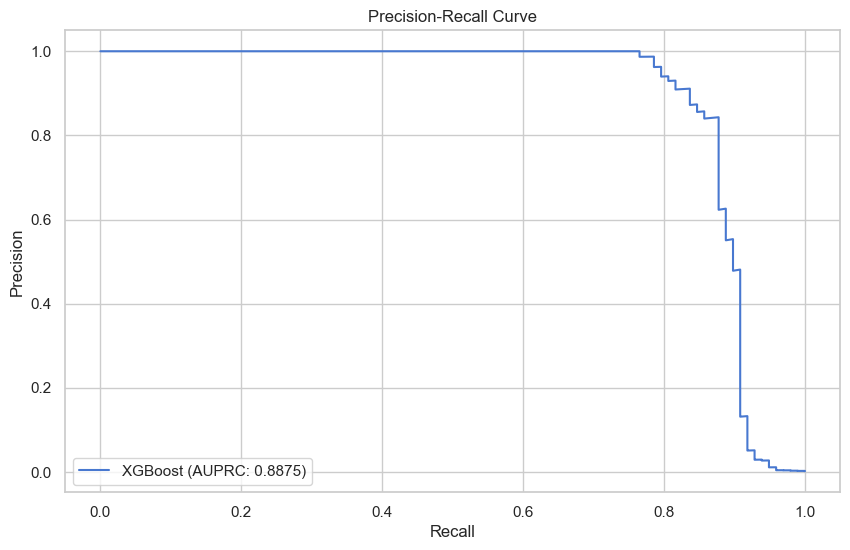

Final Model AUPRC: 0.8875


In [15]:
y_prob = xgb.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_prob)

p, r, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(10, 6))
plt.plot(r, p, label=f'XGBoost (AUPRC: {auprc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

print(f"Final Model AUPRC: {auprc:.4f}")

### 4.1. Detailed Confusion Matrix
Beyond PR curves, we use a heatmap to visualize specific misclassifications at the default threshold.

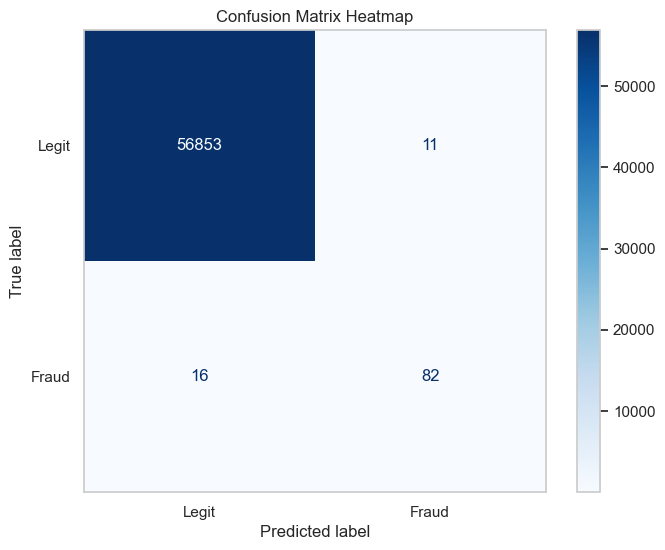

In [16]:
y_pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud']).plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.grid(False)
plt.show()

## 5. Model Calibration
Evaluation of whether the model's predicted probabilities align with actual empirical frequencies. A well-calibrated model is critical for defining risk-based intervention tiers.

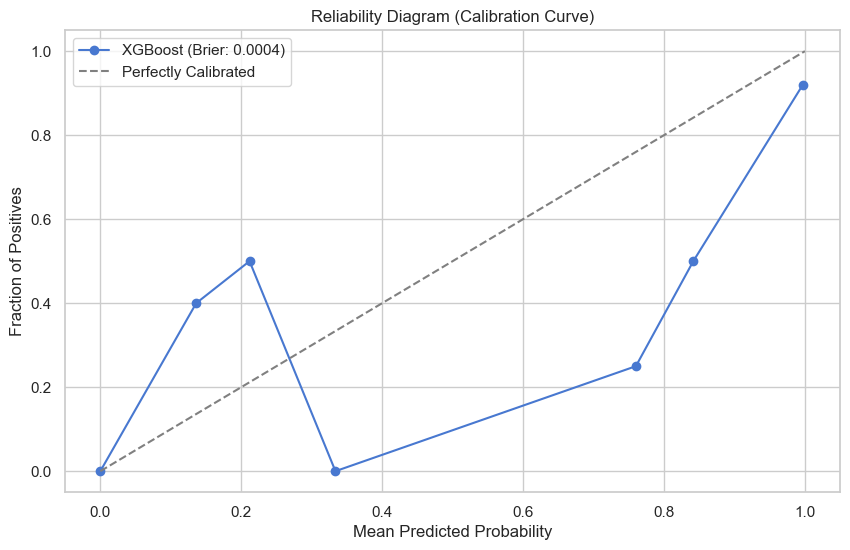

In [17]:
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
brier = brier_score_loss(y_test, y_prob)

plt.figure(figsize=(10, 6))
plt.plot(prob_pred, prob_true, marker='o', label=f'XGBoost (Brier: {brier:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Reliability Diagram (Calibration Curve)')
plt.legend()
plt.show()

## 4.1. Threshold Optimization
Finding the classification threshold that maximizes the F1-score to balance precision and recall on this imbalanced dataset.

Optimal Threshold: 0.77
Max F1 Score: 0.8723


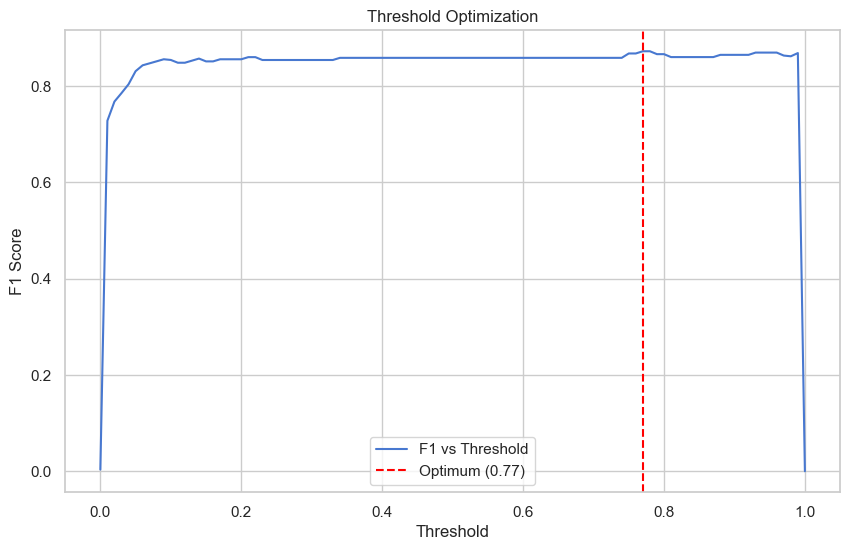

In [18]:
thresholds = np.linspace(0, 1, 101)
f1_scores = [f1_score(y_test, y_prob >= t) for t in thresholds]
opt_thresh = thresholds[np.argmax(f1_scores)]
max_f1 = np.max(f1_scores)

print(f"Optimal Threshold: {opt_thresh:.2f}")
print(f"Max F1 Score: {max_f1:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, label='F1 vs Threshold')
plt.axvline(opt_thresh, color='red', linestyle='--', label=f'Optimum ({opt_thresh:.2f})')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Optimization')
plt.legend()
plt.show()

## 6. Drift Detection Baseline
To monitor the model in production, we calculate the reference statistics (mean and standard deviation) of the features from the training set.

In [19]:
feature_baseline = {}
for col in X_train.columns:
    feature_baseline[col] = {
        "mean": float(X_train[col].mean()),
        "std": float(X_train[col].std())
    }
print("Feature baseline statistics calculated for drift detection.")

Feature baseline statistics calculated for drift detection.


## 7. Model Interpretability (SHAP)
Using SHAP to understand how features contribute to the model's predictions.

Feature Importance (SHAP Bar Plot)


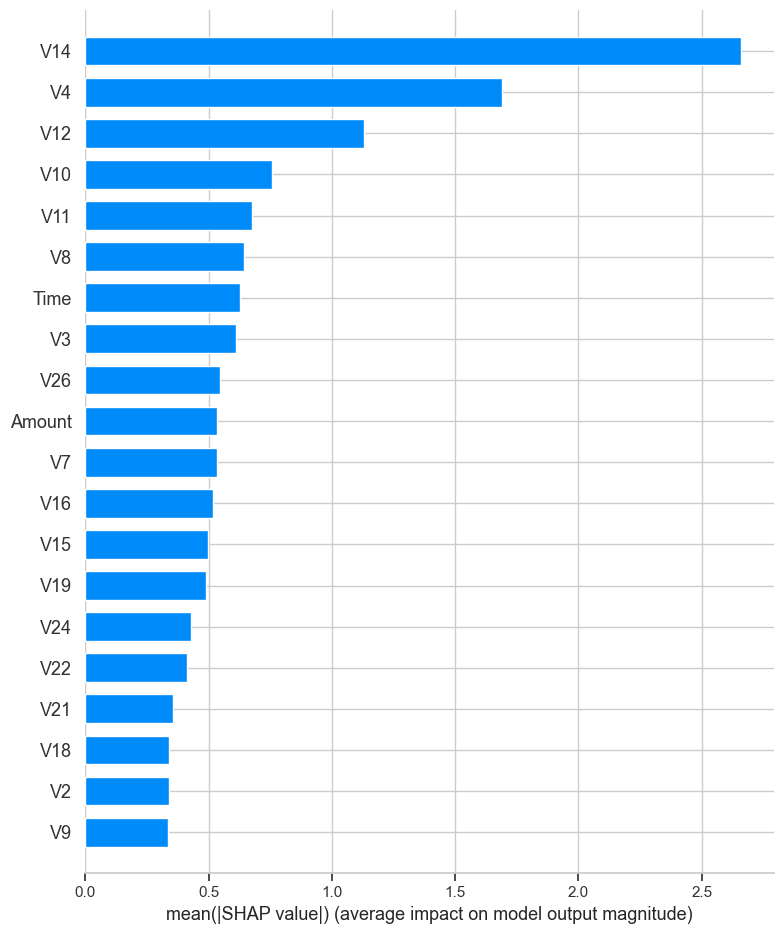

In [20]:
# Global Explanation
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print("Feature Importance (SHAP Bar Plot)")
shap.summary_plot(shap_values, X_test, plot_type="bar")

### Inference: Global Importance
The bar plot above shows which features have the greatest overall impact on the model's decisions. For this dataset, PCA features like `V17`, `V12`, and `V14` are typically the most discriminative for fraud detection.

Explaining fraud case at index 840...


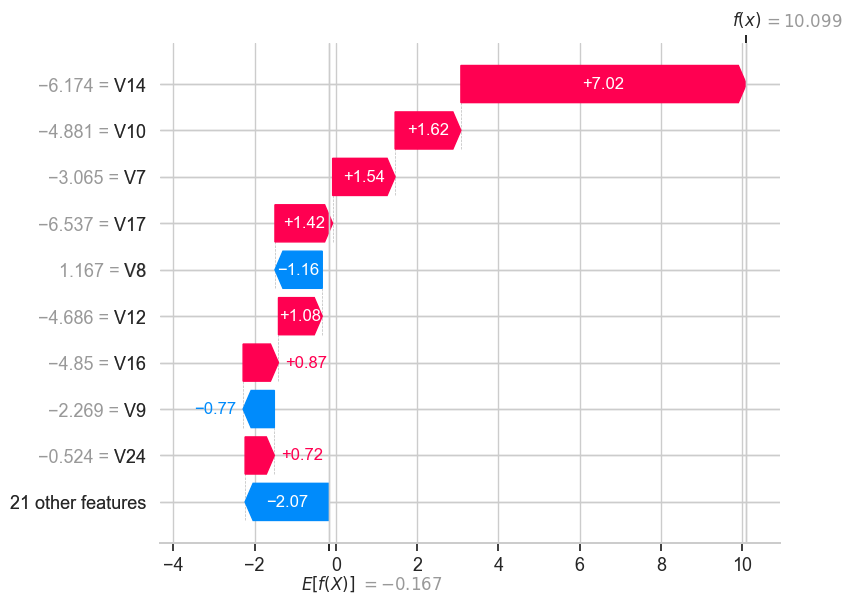

In [21]:
# Local Explanation: Single Fraud Case
fraud_idx = np.where(y_test == 1)[0][0]
print(f"Explaining fraud case at index {fraud_idx}...")

shap_obs = explainer(X_test.iloc[fraud_idx:fraud_idx+1])
shap.plots.waterfall(shap_obs[0])

### Inference: Waterfall Plot
The waterfall plot explains a specific prediction. Red bars indicate features that increased the fraud probability for this instance, while blue bars indicate features that decreased it. This allows for granular, case-by-case auditability.

## 8. Learning Curves
Analyzing how model performance scales with data to diagnose bias vs. variance issues.

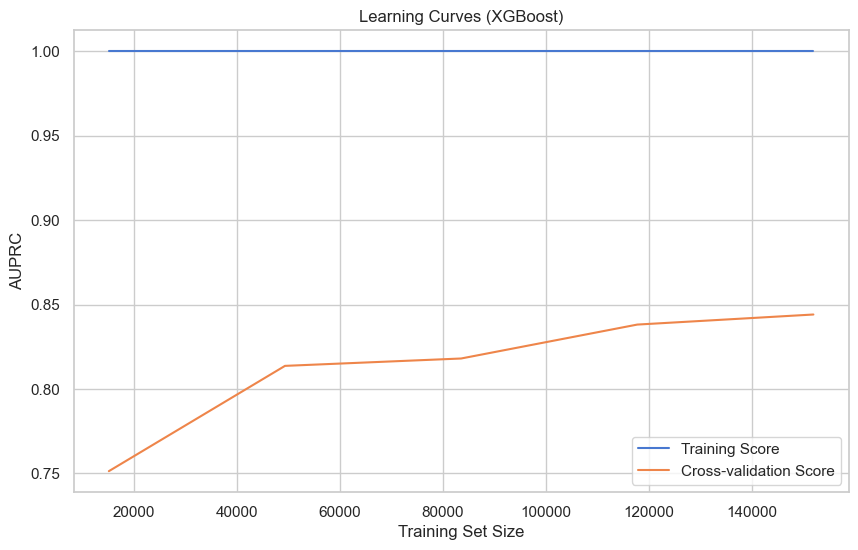

In [22]:
train_sizes, train_scores, test_scores = learning_curve(
    xgb, X_train, y_train, cv=3, scoring='average_precision', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-validation Score')
plt.xlabel('Training Set Size')
plt.ylabel('AUPRC')
plt.title('Learning Curves (XGBoost)')
plt.legend()
plt.show()

## 9. Model Persistence
Saving the model and related artifacts to disk for the final microservice.

In [23]:
MODEL_DIR = "../model"
os.makedirs(MODEL_DIR, exist_ok=True)

model_artifact = {
    "model": xgb,
    "scaler": scaler,
    "feature_baseline": feature_baseline,
    "feature_names": X_train.columns.tolist(),
    "auprc": auprc,
    "optimal_threshold": opt_thresh
}

joblib.dump(model_artifact, os.path.join(MODEL_DIR, "model.pkl"))
print(f"All artifacts saved to {MODEL_DIR}/model.pkl")

All artifacts saved to ../model/model.pkl
